In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Pre-processing

In [2]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
data = iris['data']
target = iris['target']

In [4]:
train_x, test_x, train_y, test_y = train_test_split(
    data, target, random_state=42,test_size=0.2
)

In [5]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(120, 4)
(120,)
(30, 4)
(30,)


### Model Training

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42,
    learning_rate_init=0.001,
    batch_size=32,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    alpha=0.0001
)

In [7]:
mlp.fit(train_x, train_y)

MLPClassifier(batch_size=32, early_stopping=True, hidden_layer_sizes=(32, 16),
              max_iter=1000, n_iter_no_change=20, random_state=42,
              validation_fraction=0.2)

In [8]:
y_pred = mlp.predict(test_x)

In [9]:
accuracy_score(y_pred, test_y)

0.9666666666666667

### Plotting

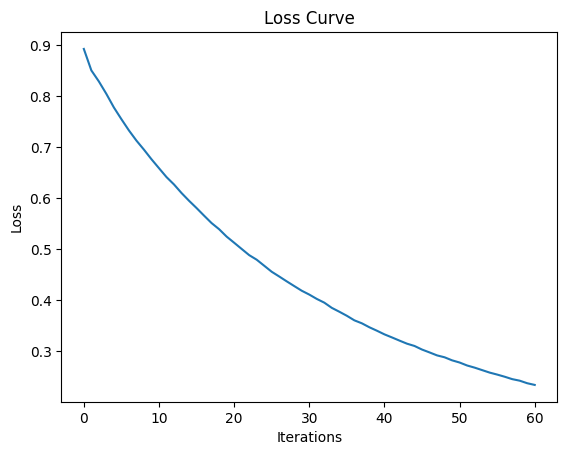

In [10]:
loss_values = mlp.loss_curve_
plt.plot(loss_values)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()



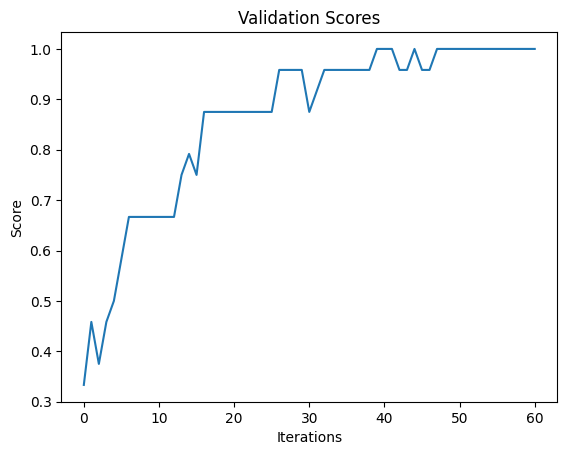

In [11]:

validation_scores = mlp.validation_scores_
plt.xlabel("Iterations")
plt.ylabel("Score")
plt.title("Validation Scores")
plt.plot(validation_scores)
plt.show()

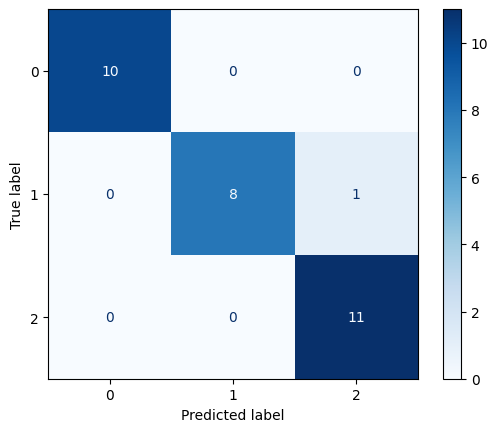

In [12]:
c_matrix = confusion_matrix(test_y, y_pred)
disp = ConfusionMatrixDisplay(c_matrix)
disp.plot(cmap='Blues')

In [13]:
print(classification_report(test_y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

